<a href="https://colab.research.google.com/github/tochirgb/EcoEarn/blob/main/CGCNNnew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch_geometric
from mp_api.client import MPRester
import pymatgen
print("torch", torch.__version__, "| PyG", torch_geometric.__version__)
print("all imports OK")

torch 2.11.0+cu128 | PyG 2.8.0
all imports OK


In [ ]:
from mp_api.client import MPRester
import pickle

API_KEY = "3U2JV341sDokCRGbnuzEBLsKeNTEODnR"

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        num_sites=(1, 20),                 # keep cells small for 16 GB
        fields=["material_id", "structure",
                "formation_energy_per_atom", "band_gap"],
        num_chunks=10, chunk_size=1000,    # ~10,000 materials total
    )

# Convert to picklable tuples and save so you never re-download
data = [(d.structure, d.formation_energy_per_atom, d.band_gap)
        for d in docs
        if d.structure is not None and d.formation_energy_per_atom is not None]

with open("mp_data.pkl", "wb") as f:
    pickle.dump(data, f)

print("Downloaded and saved", len(data), "materials")

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

Downloaded and saved 10000 materials


In [ ]:
import numpy as np
import torch
from torch_geometric.data import Data

class GaussianExpansion:
    """Expand a scalar distance into a vector of Gaussian basis activations."""
    def __init__(self, dmin=0.0, dmax=8.0, n=50):
        self.centers = np.linspace(dmin, dmax, n)
        self.width = (dmax - dmin) / n
    def expand(self, distances):
        d = np.asarray(distances)[:, None]                  # (E, 1)
        return np.exp(-((d - self.centers) ** 2) / self.width ** 2)  # (E, n)

gauss = GaussianExpansion(dmin=0.0, dmax=8.0, n=50)

def structure_to_graph(structure, target, cutoff=8.0, max_neighbors=12):
    # pymatgen handles periodic images automatically
    all_neighbors = structure.get_all_neighbors(cutoff)
    src, dst, dist = [], [], []
    for i, nbrs in enumerate(all_neighbors):
        nbrs = sorted(nbrs, key=lambda n: n.nn_distance)[:max_neighbors]
        for n in nbrs:
            src.append(i)
            dst.append(n.index)        # index of the neighbor's parent atom
            dist.append(n.nn_distance)

    if len(src) == 0:                  # isolated atom edge-case; skip it
        return None

    z = torch.tensor(structure.atomic_numbers, dtype=torch.long)      # node identities
    edge_index = torch.tensor([src, dst], dtype=torch.long)           # (2, E)
    edge_attr = torch.tensor(gauss.expand(dist), dtype=torch.float)   # (E, 50)
    y = torch.tensor([target], dtype=torch.float)

    return Data(z=z, edge_index=edge_index, edge_attr=edge_attr,
                y=y, num_nodes=len(z))

In [ ]:
import pickle

with open("mp_data.pkl", "rb") as f:
    data = pickle.load(f)

TARGET = "formation_energy"   # change to "band_gap" to predict band gap

graphs = []
for structure, e_form, bgap in data:
    target = e_form if TARGET == "formation_energy" else bgap
    if target is None:
        continue
    g = structure_to_graph(structure, target)
    if g is not None:
        graphs.append(g)

torch.save(graphs, "graphs.pt")
print("Built", len(graphs), "graphs")

Built 10000 graphs


In [ ]:
import torch
from torch_geometric.loader import DataLoader
import random

graphs = torch.load("graphs.pt", weights_only=False)
random.seed(42)
random.shuffle(graphs)

n = len(graphs)
n_train, n_val = int(0.8 * n), int(0.1 * n)
train_set = graphs[:n_train]
val_set   = graphs[n_train:n_train + n_val]
test_set  = graphs[n_train + n_val:]

# normalization stats from TRAIN ONLY (never peek at val/test)
train_y = torch.tensor([g.y.item() for g in train_set])
y_mean, y_std = train_y.mean(), train_y.std()

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=128)
test_loader  = DataLoader(test_set,  batch_size=128)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool

class CGCNN(nn.Module):
    def __init__(self, num_elements=100, hidden=256, n_conv=4, edge_dim=50):
        super().__init__()
        self.embed = nn.Embedding(num_elements, hidden)     # atomic number -> vector
        self.convs = nn.ModuleList([
            CGConv(hidden, dim=edge_dim, batch_norm=True)
            for _ in range(n_conv)
        ])
        self.fc1 = nn.Linear(hidden, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, data):
        x = self.embed(data.z)                              # (num_atoms, hidden)
        for conv in self.convs:
            x = conv(x, data.edge_index, data.edge_attr)    # message passing
        x = global_mean_pool(x, data.batch)                 # (num_crystals, hidden)
        x = F.softplus(self.fc1(x))
        return self.fc2(x).view(-1)                          # (num_crystals,)

model = CGCNN(hidden=256, n_conv=4)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 1213697


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
model = model.to(device)
y_mean, y_std = y_mean.to(device), y_std.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.8, patience=10)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_mae, total_n = 0.0, 0
    torch.set_grad_enabled(train)
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        target_norm = (batch.y - y_mean) / y_std
        loss = F.mse_loss(pred, target_norm)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        # MAE back in real units (eV/atom)
        pred_real = pred * y_std + y_mean
        total_mae += (pred_real - batch.y).abs().sum().item()
        total_n += batch.num_graphs
    return total_mae / total_n

best_val = float("inf")
for epoch in range(1, 121):
    train_mae = run_epoch(train_loader, train=True)
    val_mae   = run_epoch(val_loader,   train=False)
    scheduler.step(val_mae)
    if val_mae < best_val:
        best_val = val_mae
        torch.save(model.state_dict(), "best_model.pt")
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train MAE {train_mae:.4f} | val MAE {val_mae:.4f}")

Epoch   5 | train MAE 0.2341 | val MAE 0.2361
Epoch  10 | train MAE 0.1932 | val MAE 0.2036
Epoch  15 | train MAE 0.1753 | val MAE 0.1787
Epoch  20 | train MAE 0.1650 | val MAE 0.1754
Epoch  25 | train MAE 0.1512 | val MAE 0.1688
Epoch  30 | train MAE 0.1530 | val MAE 0.1699
Epoch  35 | train MAE 0.1341 | val MAE 0.1594
Epoch  40 | train MAE 0.1362 | val MAE 0.1561
Epoch  45 | train MAE 0.1258 | val MAE 0.1769
Epoch  50 | train MAE 0.1212 | val MAE 0.1766
Epoch  55 | train MAE 0.1159 | val MAE 0.1487
Epoch  60 | train MAE 0.1202 | val MAE 0.1522
Epoch  65 | train MAE 0.1118 | val MAE 0.1390
Epoch  70 | train MAE 0.1180 | val MAE 0.1598
Epoch  75 | train MAE 0.1053 | val MAE 0.1550
Epoch  80 | train MAE 0.1050 | val MAE 0.1301
Epoch  85 | train MAE 0.1028 | val MAE 0.1468
Epoch  90 | train MAE 0.0983 | val MAE 0.1523
Epoch  95 | train MAE 0.0943 | val MAE 0.1329
Epoch 100 | train MAE 0.0959 | val MAE 0.1244
Epoch 105 | train MAE 0.0864 | val MAE 0.1154
Epoch 110 | train MAE 0.0878 | val

Test MAE: 0.1094395654948894 eV/atom


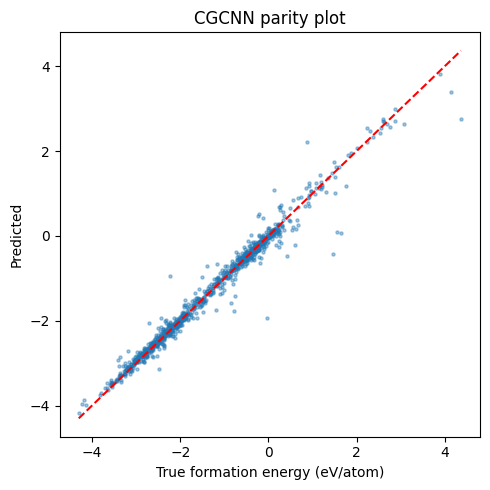

In [ ]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        p = model(batch) * y_std + y_mean
        preds += p.cpu().tolist()
        trues += batch.y.cpu().tolist()

import numpy as np
preds, trues = np.array(preds), np.array(trues)
print("Test MAE:", np.abs(preds - trues).mean(), "eV/atom")

plt.figure(figsize=(5, 5))
plt.scatter(trues, preds, s=5, alpha=0.4)
lims = [trues.min(), trues.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel("True formation energy (eV/atom)")
plt.ylabel("Predicted")
plt.title("CGCNN parity plot")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# reload best weights (safe even if already in memory)
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()
print("Model loaded. Target it was trained on:", TARGET)

Model loaded. Target it was trained on: formation_energy


In [ ]:
# Screen a focused chemical space. Here: oxides with small cells.
# Change `elements` / `chemsys` to whatever space you care about.
with MPRester(API_KEY) as mpr:
    candidates_raw = mpr.materials.summary.search(
        elements=["O"],                    # must contain oxygen (oxides)
        num_sites=(1, 20),                 # keep graphs small
        fields=["material_id", "formula_pretty", "structure",
                "formation_energy_per_atom", "band_gap", "energy_above_hull"],
        num_chunks=20, chunk_size=1000,    # up to ~20,000 candidates
    )

candidates = [c for c in candidates_raw if c.structure is not None]
print("Candidates to screen:", len(candidates))

Retrieving SummaryDoc documents:   0%|          | 0/20000 [00:00<?, ?it/s]

Candidates to screen: 20000


In [ ]:
@torch.no_grad()
def predict_structures(structures, batch_size=256):
    """Convert structures to graphs and predict in batches. Returns kept indices + predictions."""
    graphs, keep_idx = [], []
    for i, s in enumerate(structures):
        g = structure_to_graph(s, target=0.0)   # dummy target; we only want the prediction
        if g is not None:
            graphs.append(g)
            keep_idx.append(i)
    loader = DataLoader(graphs, batch_size=batch_size)
    preds = []
    for batch in loader:
        batch = batch.to(device)
        p = model(batch) * y_std + y_mean       # back to real units (eV/atom)
        preds += p.cpu().tolist()
    return keep_idx, preds

import time
t0 = time.time()
structs = [c.structure for c in candidates]
keep_idx, preds = predict_structures(structs)
print(f"Predicted {len(preds)} materials in {time.time()-t0:.1f}s "
      f"({(time.time()-t0)/max(len(preds),1)*1000:.1f} ms each)")

Predicted 20000 materials in 335.0s (16.7 ms each)


In [ ]:
rows = []
for j, i in enumerate(keep_idx):
    c = candidates[i]
    rows.append({
        "material_id": c.material_id,
        "formula": c.formula_pretty,
        "predicted": preds[j],
        "true": (c.formation_energy_per_atom if TARGET == "formation_energy"
                 else c.band_gap),
        "e_above_hull": c.energy_above_hull,
    })
df = pd.DataFrame(rows)

# --- SCREENING CRITERION ---
if TARGET == "formation_energy":
    # Stability screen: most negative predicted formation energy = most stable
    screened = df.sort_values("predicted").head(20)
    print("Top 20 candidates the model predicts to be MOST STABLE:")
else:
    # Band-gap screen: keep predictions inside a target window (e.g. solar absorbers)
    LO, HI = 1.0, 1.5
    screened = df[(df["predicted"] >= LO) & (df["predicted"] <= HI)] \
                 .sort_values("predicted")
    print(f"Candidates with predicted band gap in [{LO}, {HI}] eV:")

screened

Top 20 candidates the model predicts to be MOST STABLE:


,material_id,formula,predicted,true,e_above_hull
18014,mp-1518724,BaGdCrFeO6,-9.457736,-5.153568,0.000000
6314,mp-1184349,FeRhO3,-6.738133,-0.364199,1.037876
6507,mp-1187220,TaFeO3,-5.753444,-2.140557,0.538212
6443,mp-1186220,NbFeO3,-4.778703,-1.910904,0.555858
2469,mp-675834,La3O2F5,-4.322567,-4.234271,0.115918
837,mp-35555,LaOF,-4.157150,-4.195509,0.061199
11855,mp-676605,Y6O5F8,-4.148733,-4.217330,0.039172
747,mp-8111,LaOF,-4.145310,-4.256708,0.000000
12426,mp-758174,Y6O5F8,-4.136470,-4.203792,0.052711
718,mp-1072193,ErOF,-4.120153,-4.288221,0.000000


In [ ]:
# Because MP gave us true values, we can verify the model's predictions on this pool
mae = (df["predicted"] - df["true"]).abs().mean()
print(f"Screening MAE vs. true values: {mae:.4f}")

# How many of your top-20 stable picks are ACTUALLY near the hull (truly stable)?
if TARGET == "formation_energy":
    near_hull = (screened["e_above_hull"] < 0.05).sum()
    print(f"{near_hull}/20 of the top picks are genuinely near the convex hull "
          f"(e_above_hull < 0.05 eV/atom)")

Screening MAE vs. true values: 0.1863
10/20 of the top picks are genuinely near the convex hull (e_above_hull < 0.05 eV/atom)
